# Exercise 2

In [76]:
import numpy as np
np.random.seed(12345)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.optimizers import Adam, RMSprop, SGD
import keras_tuner as kt
import tensorflow.random as tf_r
tf_r.set_seed(12345)
%run plot.py

In [77]:
drift,stdev,N,L,Z, pattern_amplitude, pattern_period, cat = 5, 50, 10000, 60, 1, 500, 12,3

## 1. Generate data

In [78]:

def generate_data(drift,stdev,N,L,Z, pattern_amplitude, pattern_period, cat):
    os.makedirs("DATA", exist_ok=True)
    x = np.zeros(shape=(N,L,Z))
    print(x.shape)
    y = np.zeros(shape=(N))
    one_hot = np.zeros((N,cat))
    y = (np.indices(y.shape)[0] % cat).astype(int)
    #y= y.reshape(N)
    def pattern(i,z,a):
        return int(a*np.sin((np.pi*i)/z))
    
    jump = lambda drift, stdev: int(np.random.normal(drift,stdev))
    
    for k in range(Z):
        d = x[:,:,k] # Shape: (N, L)
        for i in range(N):
            if i>0:
                d[i][0] = d[i-1][-1] + jump(drift,stdev) # first step of the new sample starts from the last point of the previous one
            
            for j in range(1,L):
                d[i][j] = d[i][j-1] + jump(drift,stdev) # random walk with bias
                
            #y[i] = i%3 # assign class labels (0,1,2)
            ##y[i] = random.randint(0,2) # random assingment
            if y[i]>0:
                j0 = np.random.randint(0,L-1-pattern_period) # random starting point for the pattern
                ###print(i,j0,j1)
                sign = cat-(cat-1)*y[i] # sign of the pattern: + for class 1, - for class 2
                for j in range(pattern_period):
                    d[i][j0+j] += sign*pattern(j,pattern_period,pattern_amplitude) # add pattern to the timeseries
        x[:,:,k] = d
    one_hot[np.arange(N), y] = 1.0
    #y = y.reshape(N,cat)
    if Z == 1:
        x = x.reshape(N,L)
    str0 = f'ts_L{L}_Z{pattern_period}_A{pattern_amplitude}_DX{stdev}_bias{drift}_N{N}_D{Z}.npy'
    fname='DATA/x_'+str0
    np.save(fname,x)
    fname='DATA/y_'+str0
    np.save(fname,one_hot)
    return x, one_hot

x,y= generate_data(drift,stdev,N,L,Z, pattern_amplitude, pattern_period, cat)

x.shape, y.shape

(10000, 60, 1)


((10000, 60), (10000, 3))

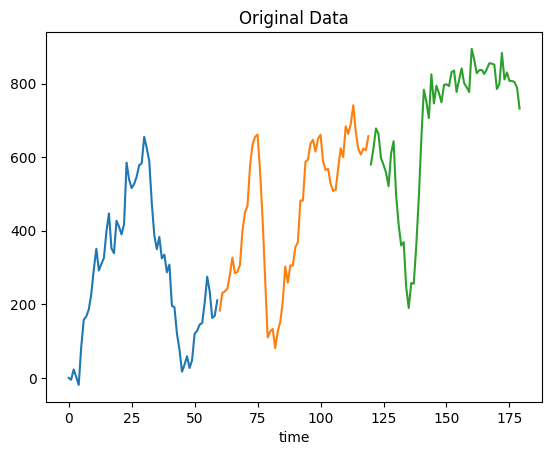

In [79]:
Show_data(x,L,"Original Data")

In [80]:
def load_data(drift, stdev, N, L, Z, pattern_amplitude, pattern_period, perc_train=0.7, perc_valid=0.15, perc_test=0.15):
    str0 = f'ts_L{L}_Z{pattern_period}_A{pattern_amplitude}_DX{stdev}_bias{drift}_N{N}_D{Z}.npy'
    
    x = np.load(f'DATA/x_{str0}') # Load once outside the loop
    y = np.load(f'DATA/y_{str0}')
    
    N = x.shape[0]
    N_train = int(perc_train * N)
    N_valid = int(perc_valid * N)

    # Split 3D arrays directly
    x_train, y_train = x[:N_train], y[:N_train]
    x_valid, y_valid = x[N_train:N_train+N_valid], y[N_train:N_train+N_valid]
    x_test, y_test = x[N_train+N_valid:], y[N_train+N_valid:]

    # Calculate mean/std across the 'L' dimension (axis=1) 
    # This preserves the (N, Z) shape for scaling
    def scale(data,Z):
        # 1. Ensure 3D shape: (N, L, Z)
        N, L = data.shape[0], data.shape[1]
        data = data.reshape(N, L, Z)
        for z in range(Z):
            data_m = data[:,:,z].mean(axis=1)
            data_std = data[:,:,z].std(axis=1)
            
            #print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
            

            # rescale with variance on the training set
            for i in range(N):
                #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
                #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
                data[i] = (data[i]-data_m[i])/ data_std.mean(axis=0)
        
        
        return data

    x_train = scale(x_train, Z)
    x_valid = scale(x_valid, Z)
    x_test = scale(x_test, Z)
    if Z == 1:
        x_train = x_train.reshape(x_train.shape[0], L,1)
        x_valid =  x_valid.reshape(x_valid.shape[0], L,1)
        x_test =  x_test.reshape(x_test.shape[0], L,1)
    else:
        x_train = x_train.reshape(x_train.shape[0], L, Z)
        x_valid =  x_valid.reshape(x_valid.shape[0], L, Z)
        x_test =  x_test.reshape(x_test.shape[0], L, Z)
    return (x_train, y_train), (x_valid, y_valid), (x_test, y_test)

In [81]:
(x_train, y_train), (x_valid, y_valid), (x_test, y_test) = load_data(drift,stdev,N,L,Z, pattern_amplitude, pattern_period)
y_train.shape, y_valid.shape, x_train.shape, x_valid.shape

((7000, 3), (1500, 3), (7000, 60, 1), (1500, 60, 1))

In [82]:
#print(x_train[:,:,0]-x_train[:,:,1])

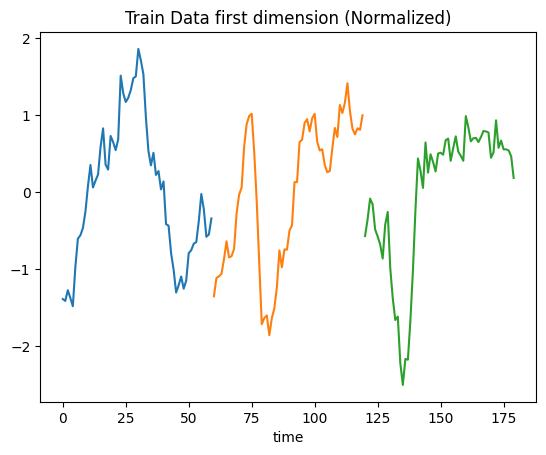

In [83]:
Show_data(x_train,L, "Train Data first dimension (Normalized)")
#Show_data(x_train[:,:,1],L, "Train Data second dimension (Normalized)")

## 2. Study of the amplitude

In [84]:
amplitude_range = np.linspace(1,15,10)
for A in amplitude_range:
    x,y= generate_data(drift,stdev,N,L,Z, stdev*A, pattern_period, cat)

(10000, 60, 1)
(10000, 60, 1)
(10000, 60, 1)
(10000, 60, 1)
(10000, 60, 1)
(10000, 60, 1)
(10000, 60, 1)
(10000, 60, 1)
(10000, 60, 1)
(10000, 60, 1)


In [85]:
def base_model(NCONV, NF, input_shape, n_class):
    reg = tf.keras.regularizers.l2(0.2) ## raised to 0.2 the regularization strenghts
    #reg = regularizers.l1(0.1)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                            seed=None)

    
    # challenge: at most 600 tunable parameters
    model = Sequential()
    # 
    if NCONV==1:
        # -----2-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                        kernel_initializer=ini, 
                        kernel_regularizer=reg,
                        activation='relu', 
                        input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, 
                        activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
    # 
    if NCONV==2:
        # -----1-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                        kernel_initializer=ini, 
                        kernel_regularizer=reg, ######## TRY WITHOUT !
                        activation='relu', input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))
        #model.add(Dense(10, activation='relu'))
        #model.add(Dropout(0.3))
    model.add(Dense(n_class, activation='softmax')) # softmax !
    model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=Adam(),metrics=['accuracy'])
    return model


In [86]:
base_model2 = base_model(NCONV=1, NF=5, input_shape=(L,Z), n_class=cat)
print('----- Base Model',1,'-----')
print(base_model2.summary())



----- Base Model 1 -----
Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 5)          │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                

/home/phuniverse/Desktop/master/LCP/Module_B/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


None


Kernel Size: 11, Channels: 1, Filters: 5


<positron-console-cell-87>:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


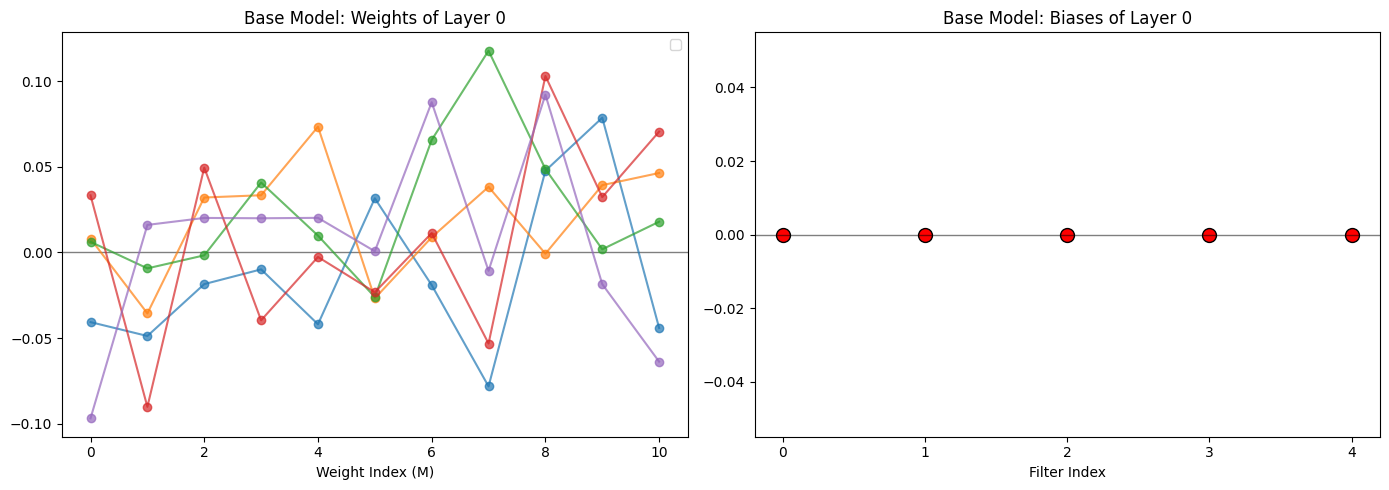

Kernel Size: 7, Channels: 5, Filters: 5


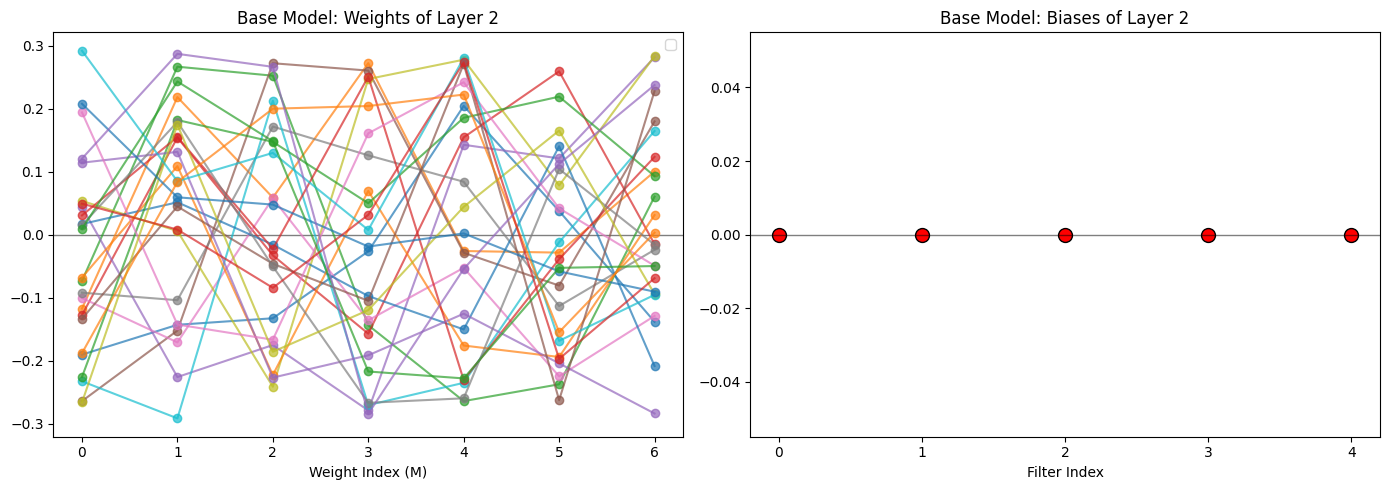

In [87]:
def Show_weights(model, l=0, label="Base Model"):
    # Extract weights: shape is (kernel_size, channels, filters)
    weights = model.layers[l].get_weights()[0] 
    biases = model.layers[l].get_weights()[1]
    
    kernel_size, n_channels, n_filters = weights.shape
    print(f"Kernel Size: {kernel_size}, Channels: {n_channels}, Filters: {n_filters}")
    
    fig, AX = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Plot 0: Filters ---
    ax = AX[0]
    ax.axhline(0, color="black", linewidth=1, alpha=0.5)
    
    # We loop through each filter
    for f in range(n_filters):
        # We loop through each channel (your 2 parallel series)
        for c in range(n_channels):
            # weights[:, c, f] gives the M weights for channel 'c' in filter 'f'
            label_str = f"Filter {f} - Ch {c}" if n_filters < 4 else None
            ax.plot(weights[:, c, f], label=label_str, marker='o', alpha=0.7)
            
    ax.set_title(f'{label}: Weights of Layer {l}')
    ax.set_xlabel('Weight Index (M)')
    if n_filters < 6: ax.legend() # Only show legend if readable

    # --- Plot 1: Biases ---
    ax = AX[1]
    ax.axhline(0, color="black", linewidth=1, alpha=0.5)
    ax.scatter(np.arange(n_filters), biases, s=100, c='red', edgecolors='k')
    
    ax.set_title(f'{label}: Biases of Layer {l}')
    ax.set_xlabel('Filter Index')
    ax.set_xticks(np.arange(n_filters))
    
    plt.tight_layout()
    plt.show()
    
Show_weights(base_model2,0)
Show_weights(base_model2,2)

In [88]:
BATCH_SIZE = 200
EPOCHS = 150

print('----- Base Model ',1,'-----\nFITTING....')
fit_or = base_model2.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_valid, y_valid),
                verbose=2, shuffle=True) 

----- Base Model  1 -----
FITTING....
Epoch 1/150
35/35 - 3s - 72ms/step - accuracy: 0.3871 - loss: 1.1039 - val_accuracy: 0.3920 - val_loss: 1.0888
Epoch 2/150
35/35 - 0s - 13ms/step - accuracy: 0.4554 - loss: 1.0691 - val_accuracy: 0.4853 - val_loss: 1.0449
Epoch 3/150
35/35 - 0s - 12ms/step - accuracy: 0.5410 - loss: 1.0146 - val_accuracy: 0.5913 - val_loss: 0.9764
Epoch 4/150
35/35 - 0s - 12ms/step - accuracy: 0.6131 - loss: 0.9443 - val_accuracy: 0.6513 - val_loss: 0.9025
Epoch 5/150
35/35 - 0s - 12ms/step - accuracy: 0.6591 - loss: 0.8797 - val_accuracy: 0.6953 - val_loss: 0.8313
Epoch 6/150
35/35 - 0s - 9ms/step - accuracy: 0.7014 - loss: 0.8096 - val_accuracy: 0.7347 - val_loss: 0.7632
Epoch 7/150
35/35 - 0s - 10ms/step - accuracy: 0.7230 - loss: 0.7560 - val_accuracy: 0.7680 - val_loss: 0.7021
Epoch 8/150
35/35 - 0s - 10ms/step - accuracy: 0.7571 - loss: 0.6983 - val_accuracy: 0.7987 - val_loss: 0.6435
Epoch 9/150
35/35 - 0s - 9ms/step - accuracy: 0.7759 - loss: 0.6538 - val_a

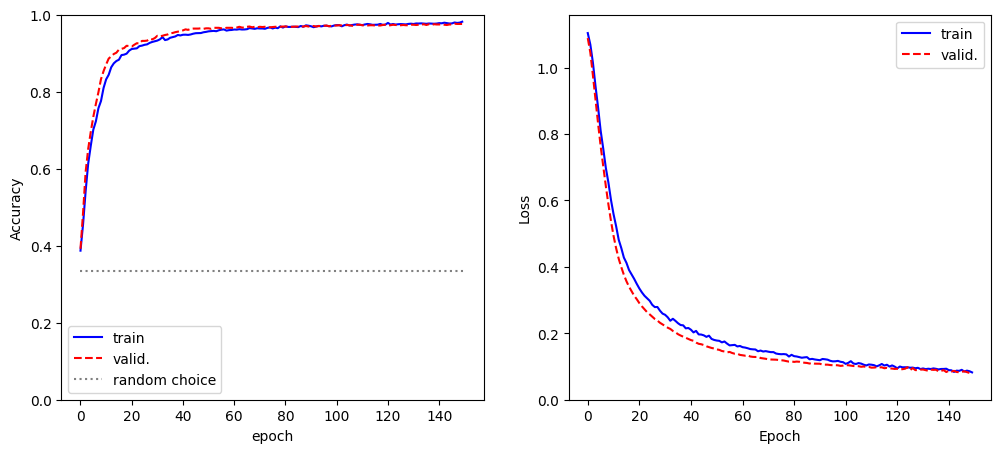

Kernel Size: 11, Channels: 1, Filters: 5


<positron-console-cell-89>:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


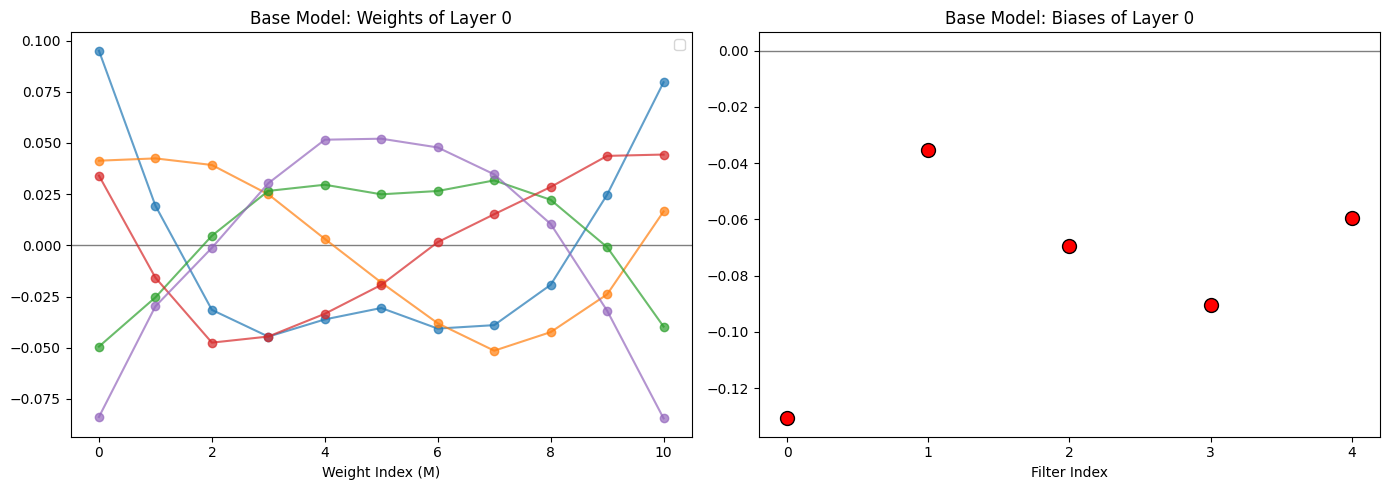

Kernel Size: 7, Channels: 5, Filters: 5


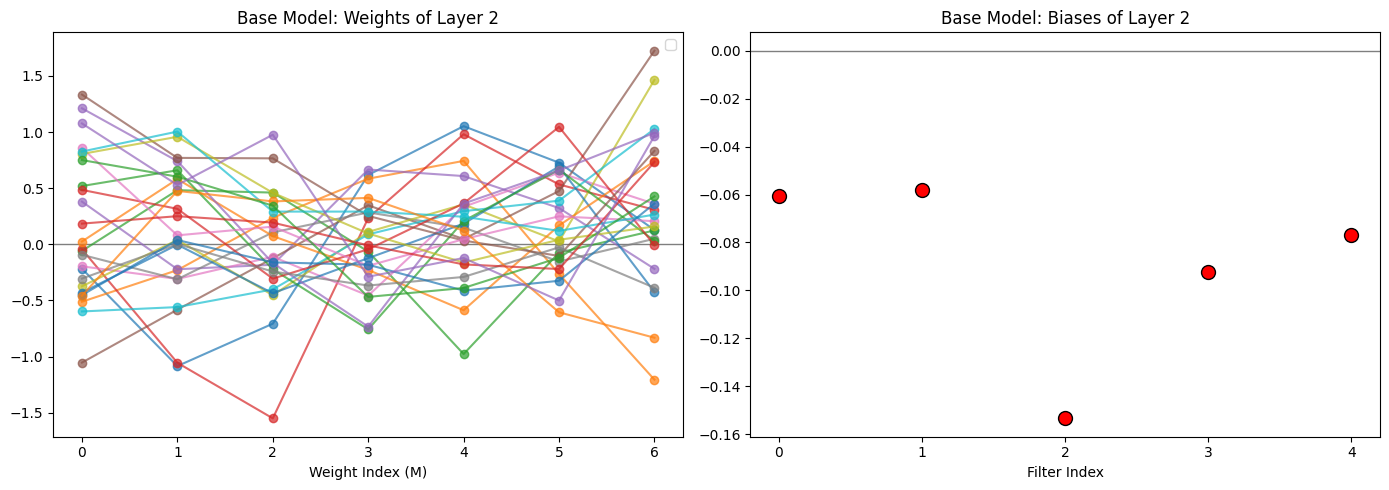

In [89]:
def Show_history(fit, cat=cat):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/cat,1/cat),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('Epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()
Show_history(fit_or)
Show_weights(base_model2,0)
Show_weights(base_model2,2)

In [90]:
A_sam_fits = {}
for A in amplitude_range:
    (x_train_al, y_train_al), (x_valid_al, y_valid_al), (x_test_al, y_test_al) = load_data(drift, stdev, N, L, Z, stdev*A, pattern_period)
    base_model_Al = base_model(NCONV=1, NF=5, input_shape=(L,Z), n_class=cat)
    fit = base_model_Al.fit(x_train_al, y_train_al,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_valid_al, y_valid_al),
                verbose=0, shuffle=True) #,callbacks=[early_stop])
    A_sam_fits[A] = (fit, base_model_Al)

/home/phuniverse/Desktop/master/LCP/Module_B/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/phuniverse/Desktop/master/LCP/Module_B/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/phuniverse/Desktop/master/LCP/Module_B/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential mode

In [91]:
def show_confusion_matrix(validations, predictions, label="Model"):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix,
                xticklabels=["absent","positive","negative"],
                yticklabels=["absent","positive","negative"],
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=1,
                cmap="GnBu",
                ax=ax_conf)
    plt.title(label+': Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


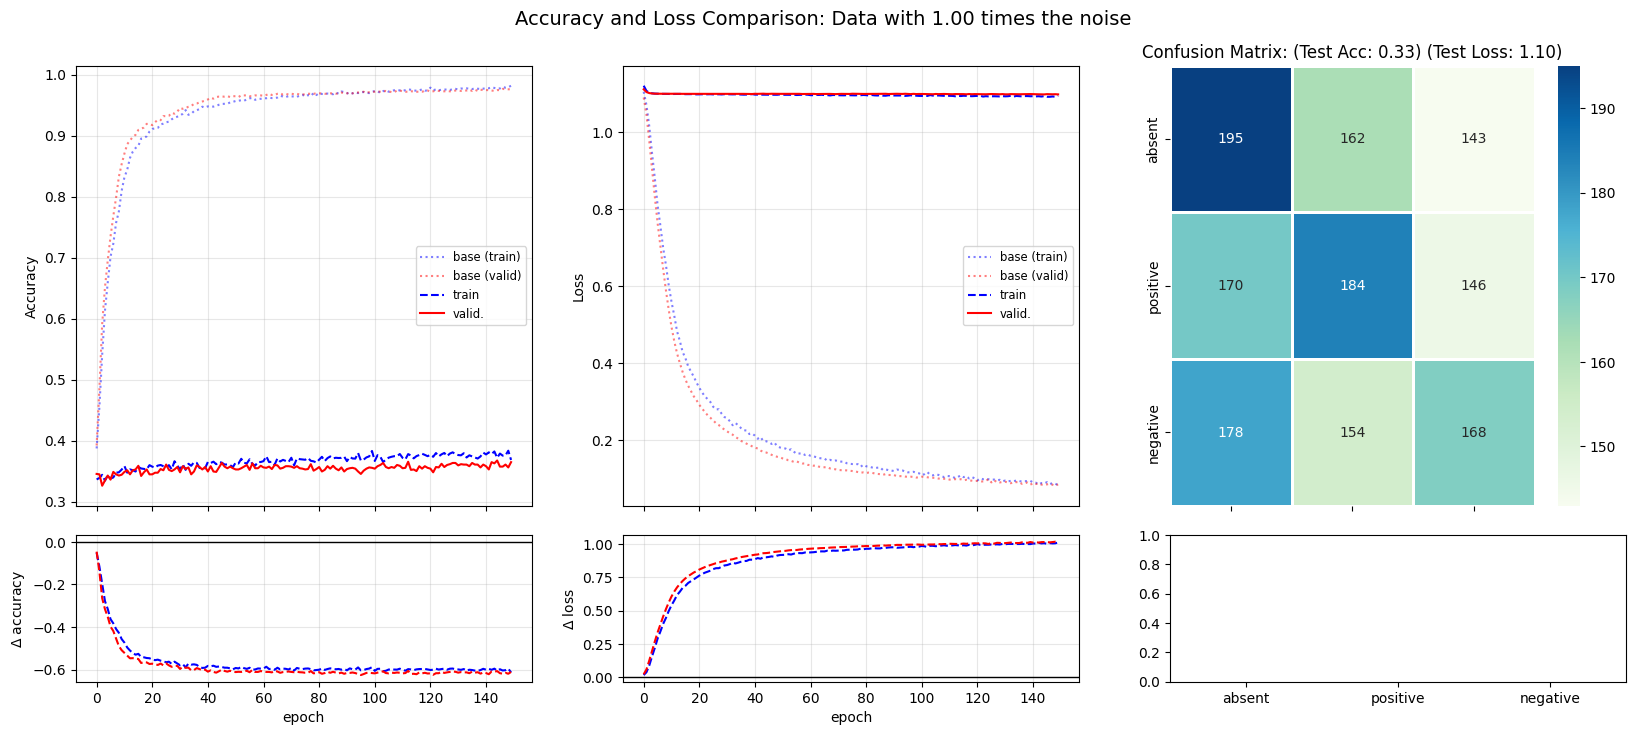

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


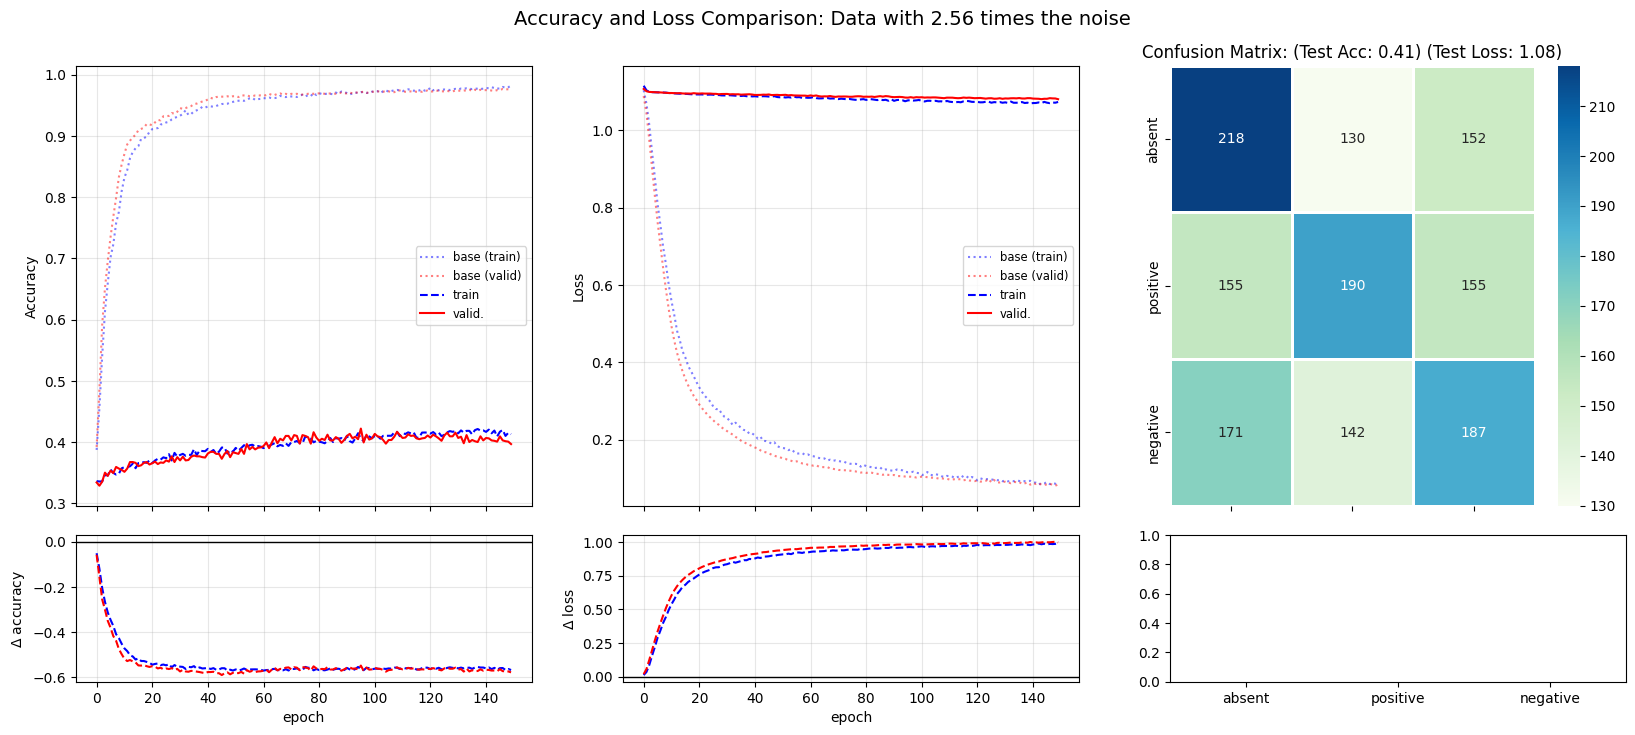

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


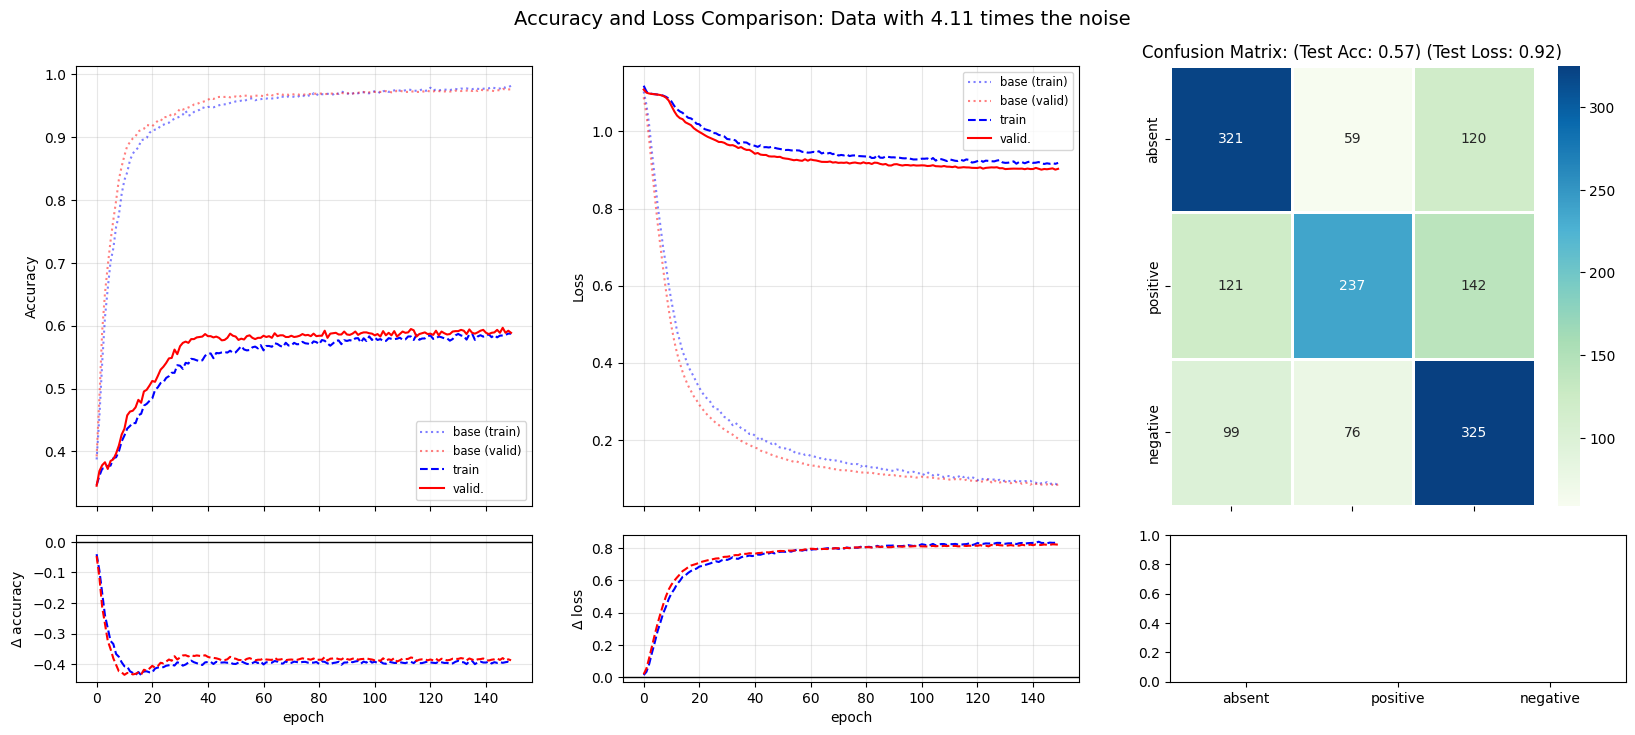

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


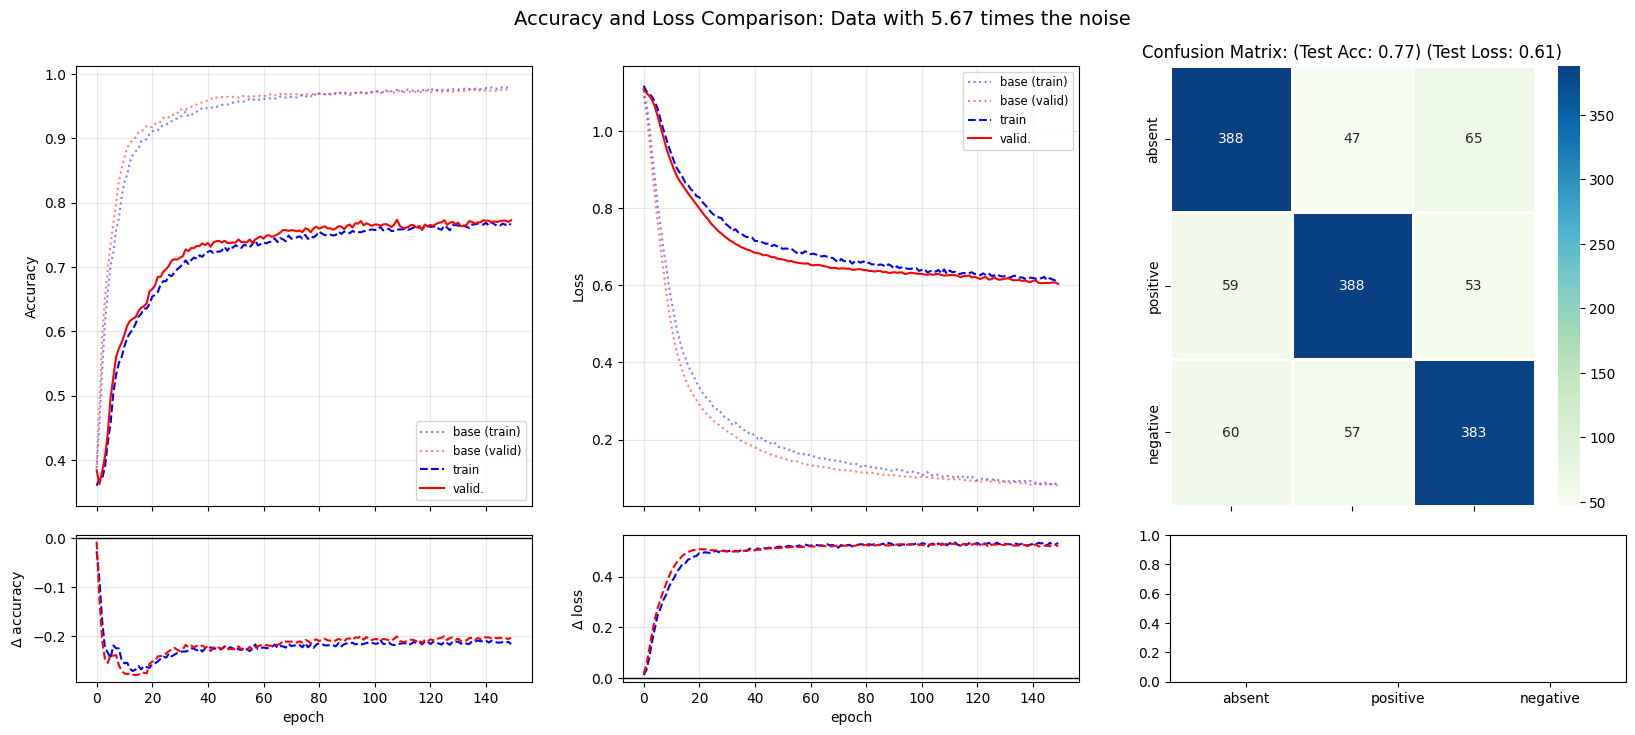

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


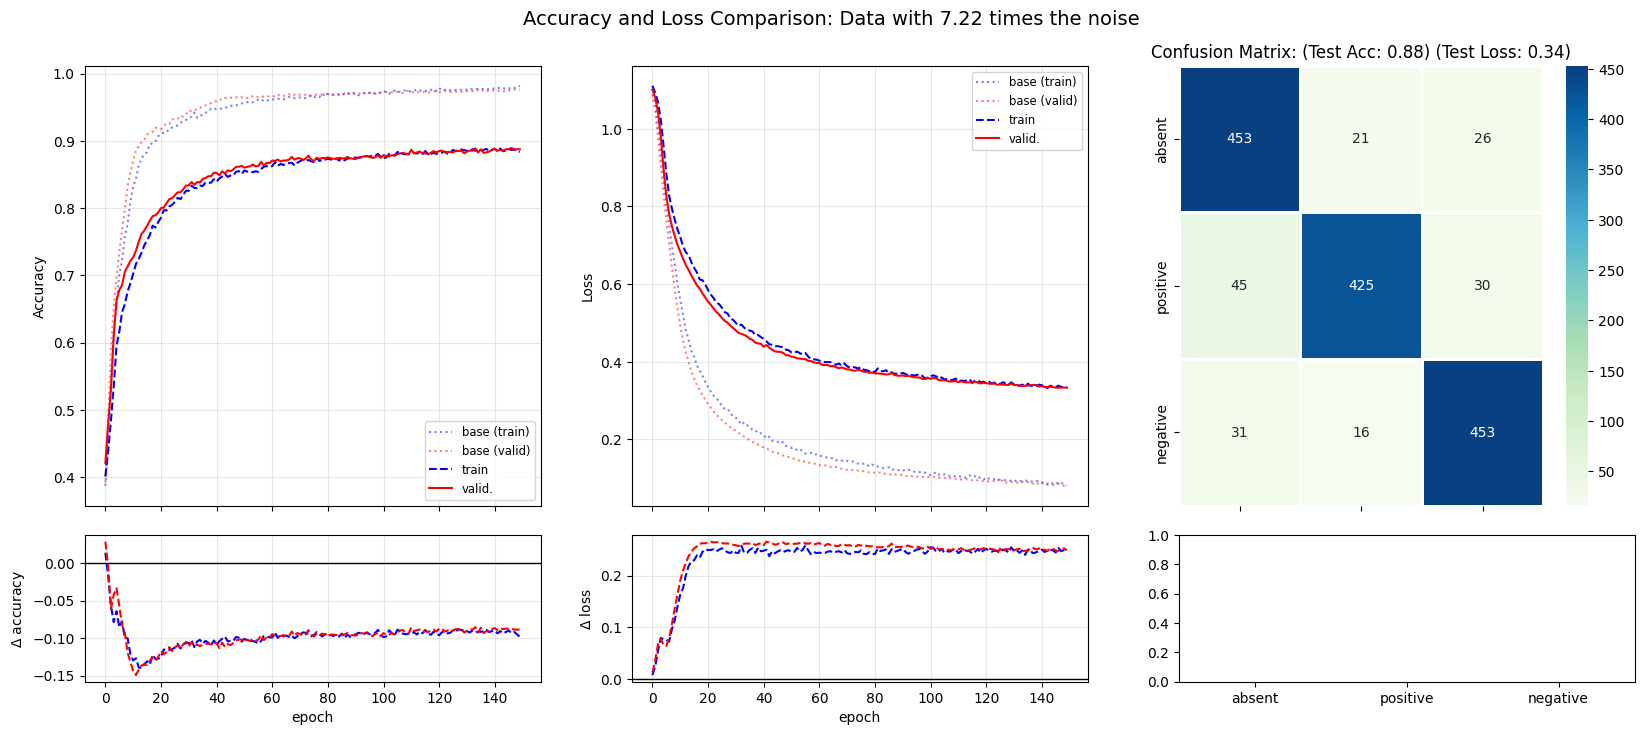

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


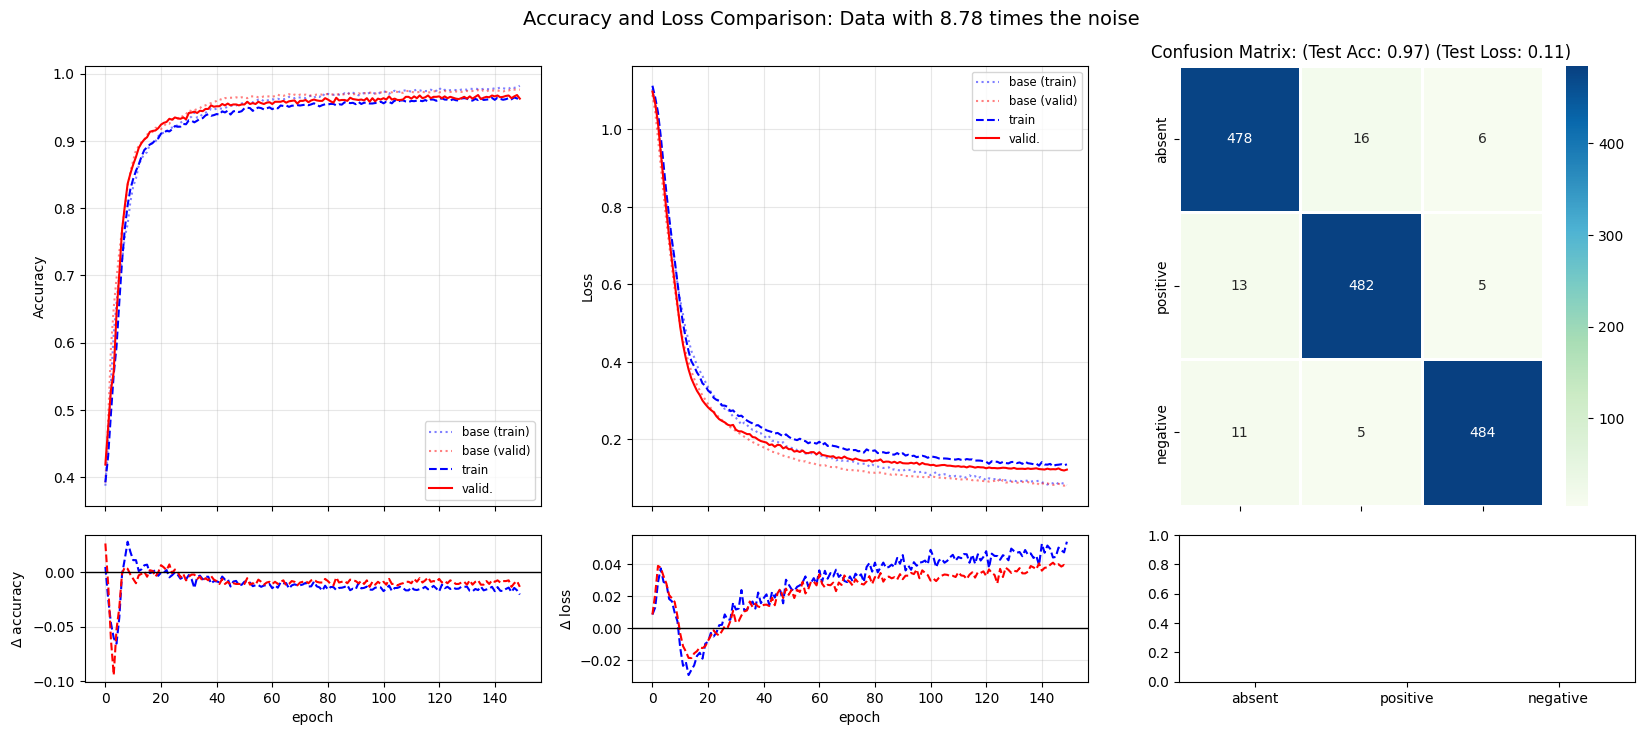

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


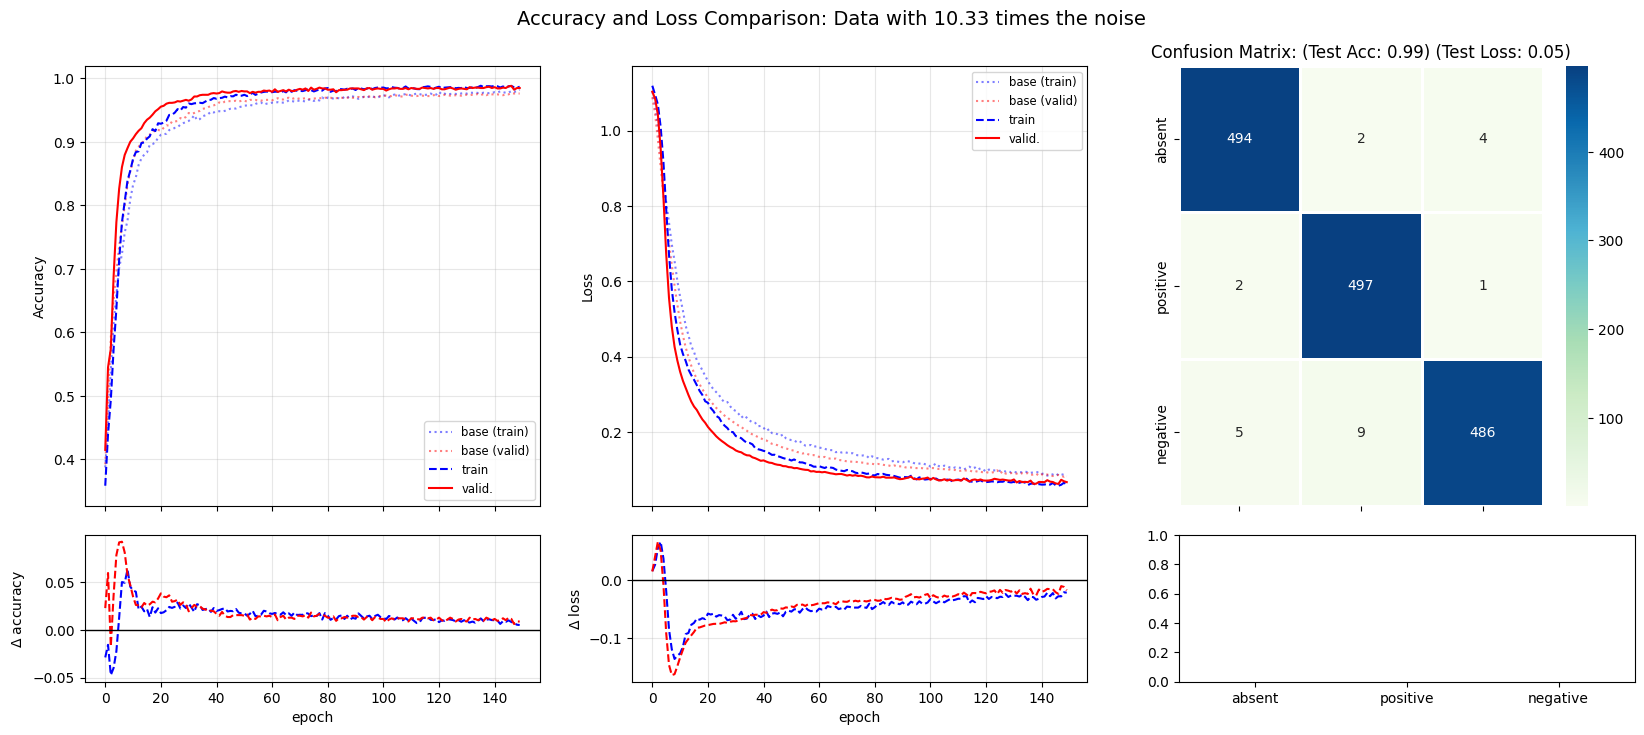

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


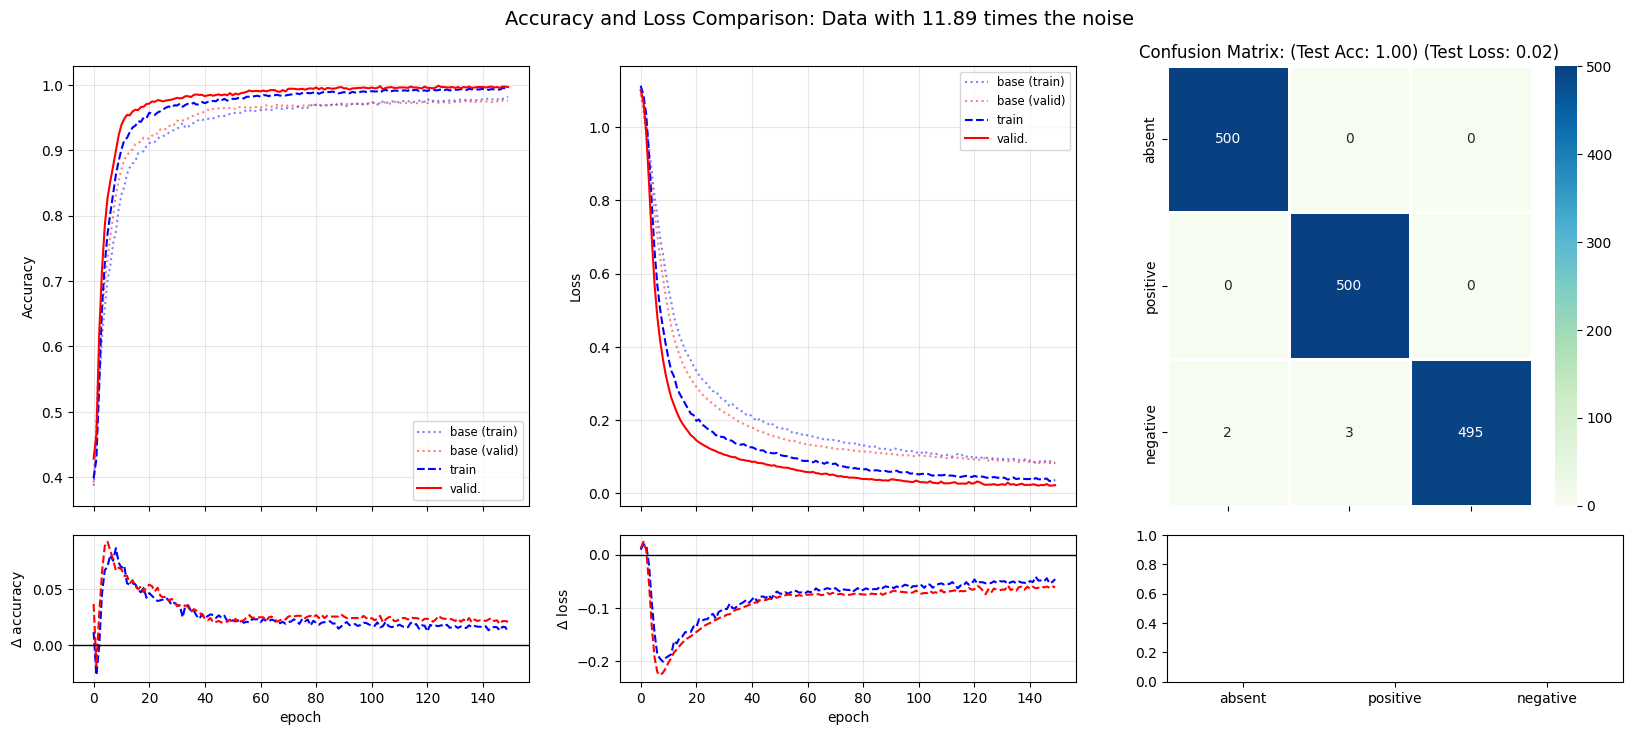

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


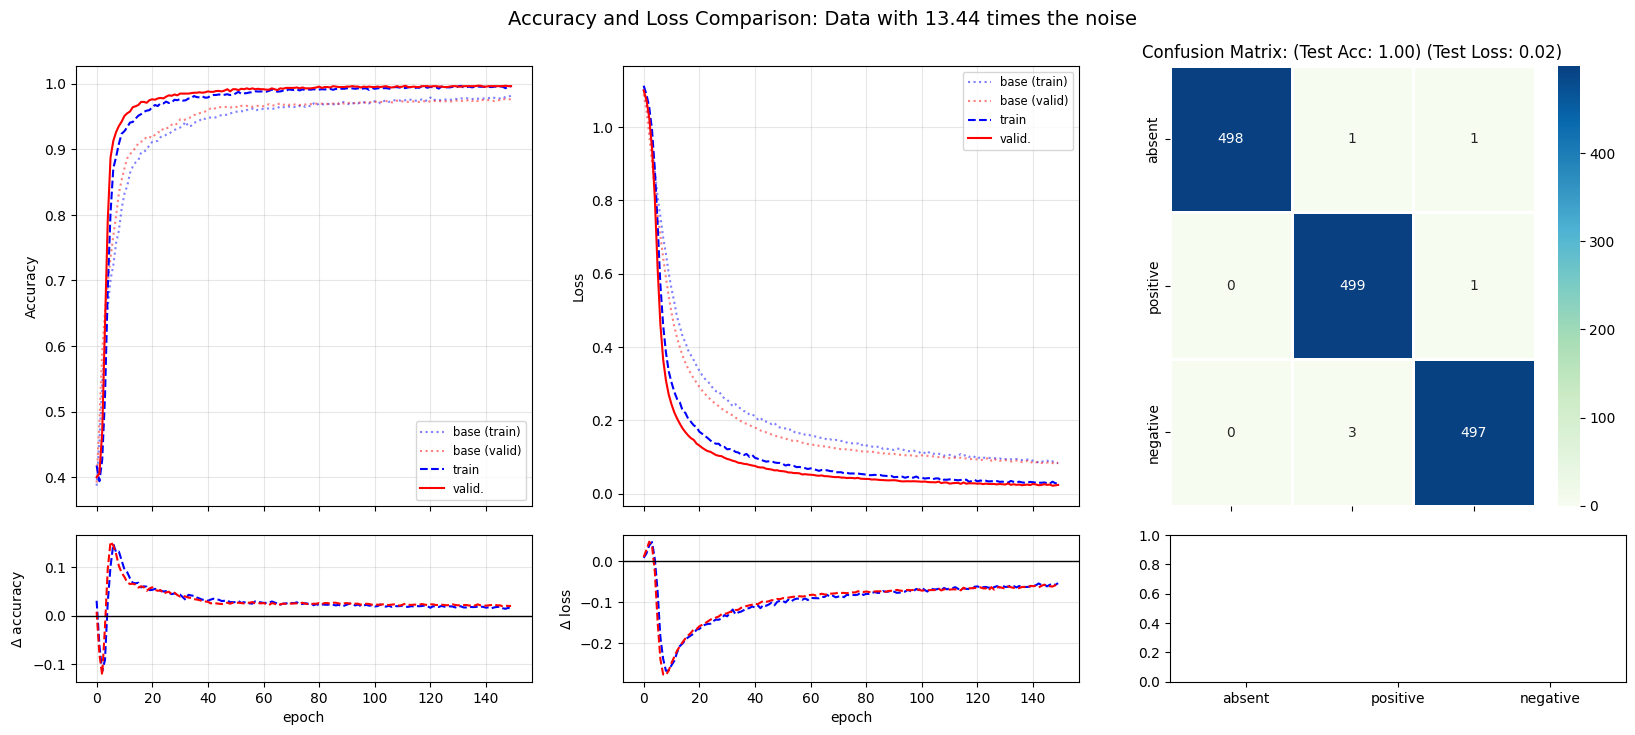

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<positron-console-cell-95>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


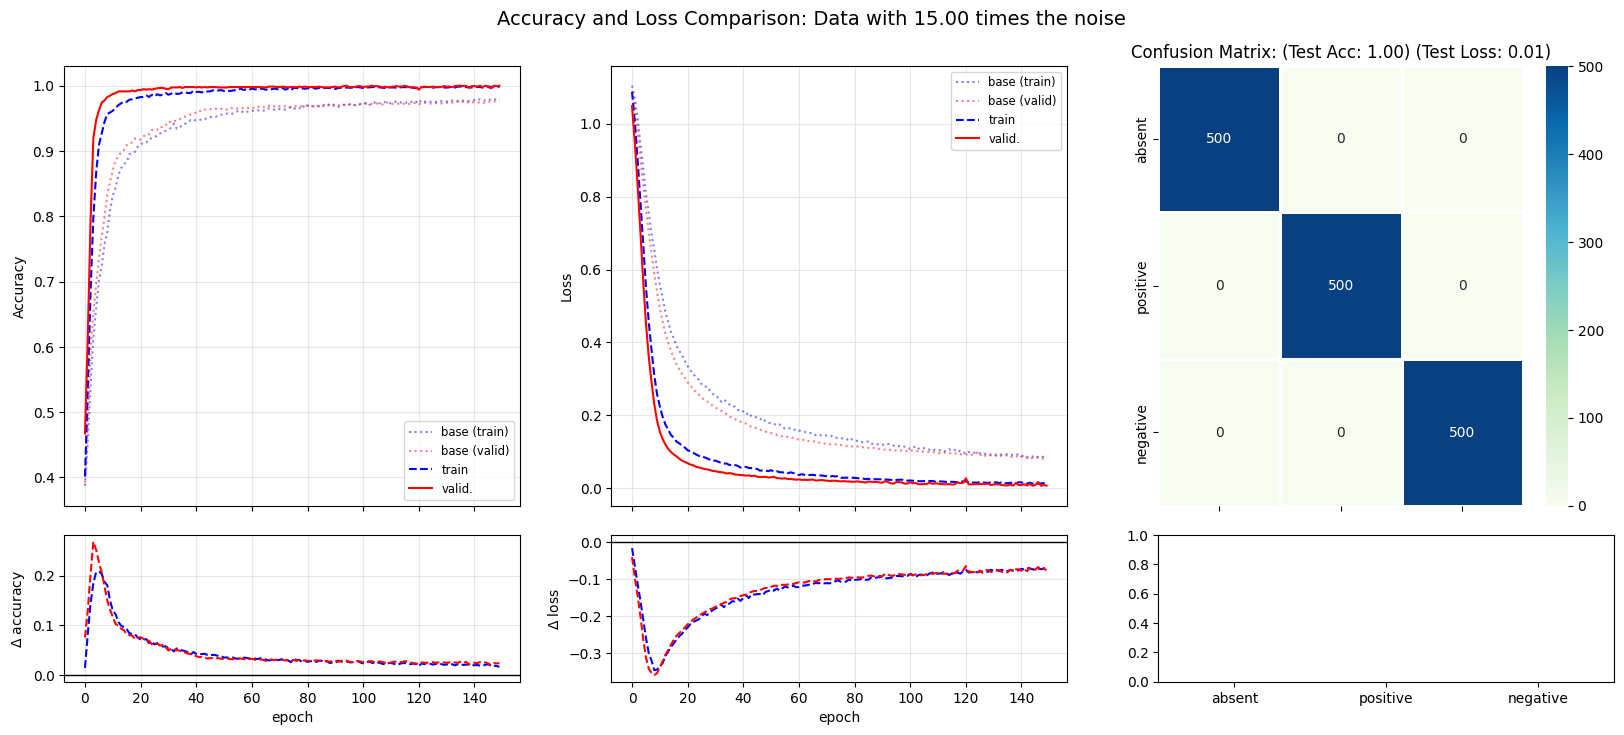

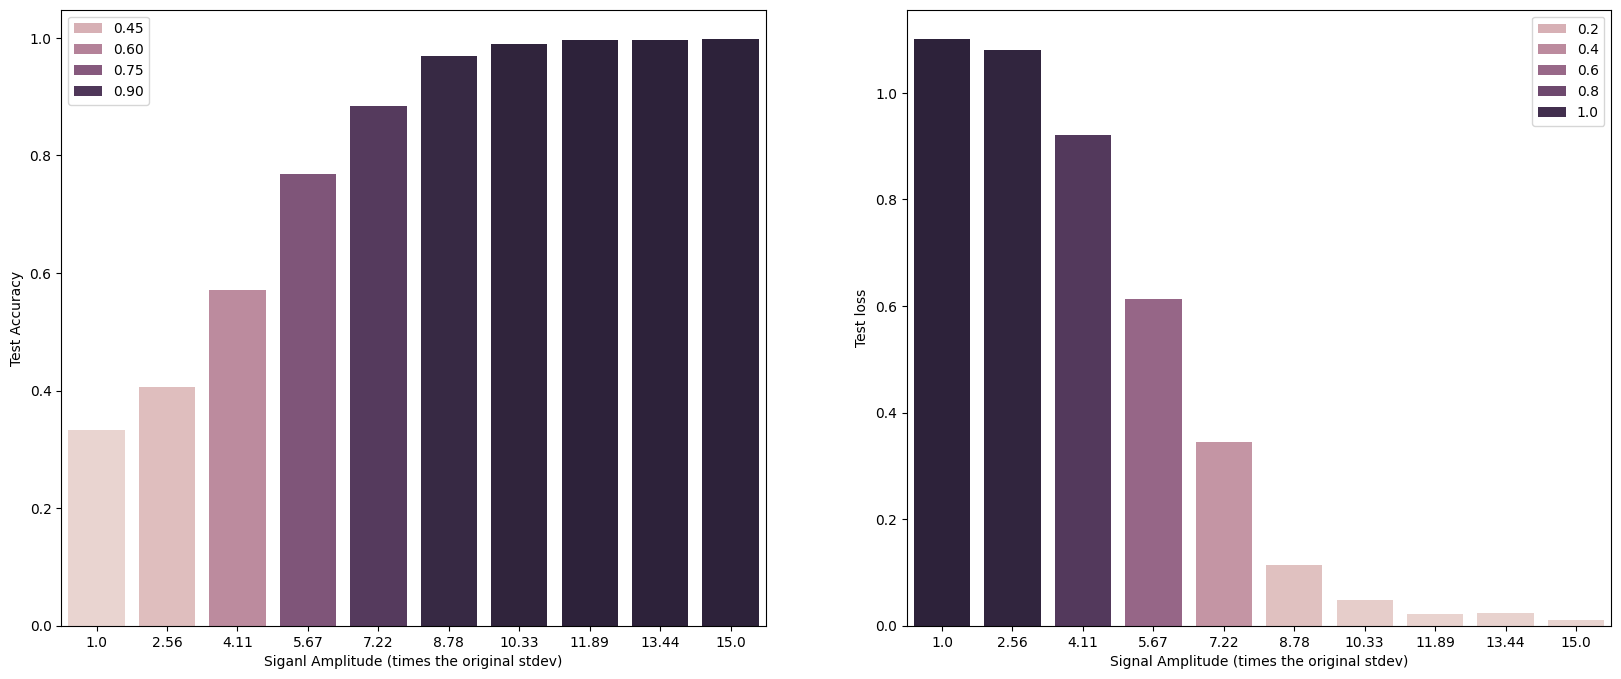

In [95]:
from sklearn import metrics
acc_list = []
loss_list = []
for key, (fit, model) in A_sam_fits.items():
    # Create a 2x2 grid with shared x-axes for the top/bottom pairs
    fig, AX = plt.subplots(2, 3, figsize=(20, 8), sharex='col', 
                           gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})
    
    
    fig.suptitle(f"Accuracy and Loss Comparison: Data with {float(key):.2f} times the noise ", fontsize=14, y=0.95)
    
    # Metrics to loop through (Accuracy and Loss)
    metrics1 = ['accuracy', 'loss']
    colors = {'train': 'b', 'valid': 'r'}
    ax_conf = AX[0, -1]
    (x_train, y_train), (x_valid, y_valid), (x_test, y_test) = load_data(drift, stdev, N, L, Z, float(key)*stdev, pattern_period)
    y_pred_val = model.predict(x_valid)
    # Take the class with the highest probability from the val predictions
    max_y_pred_val = np.argmax(y_pred_val, axis=1)
    max_y_val = np.argmax(y_valid, axis=1)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    acc_list.append(test_acc)
    loss_list.append(test_loss)
    matrix = metrics.confusion_matrix(max_y_val, max_y_pred_val)
    sns.heatmap(matrix,
                xticklabels=["absent","positive","negative"],
                yticklabels=["absent","positive","negative"],
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=1,
                cmap="GnBu",
                ax=ax_conf)
    ax_conf.set_title(f"Confusion Matrix: (Test Acc: {test_acc:.2f}) (Test Loss: {test_loss:.2f})")
    for i, metric in enumerate(metrics1):
        # --- Upper Panel: Absolute Values ---
        ax_main = AX[0, i]
        # Plot Original (Base) Model
        ax_main.plot(fit_or.history[metric], label="base (train)", c=colors['train'], alpha=0.5, ls=":")
        ax_main.plot(fit_or.history[f'val_{metric}'], label="base (valid)", c=colors['valid'], alpha=0.5, ls=":")
        # Plot Current Model
        ax_main.plot(fit.history[metric], label="train", c=colors['train'], ls="--")
        ax_main.plot(fit.history[f'val_{metric}'], label="valid.", c=colors['valid'])
        
        ax_main.set_ylabel(metric.capitalize())
        ax_main.legend(fontsize='small')
        ax_main.grid(True, alpha=0.3)
        
        # --- Lower Panel: Difference (Model - Base) ---
        ax_diff = AX[1, i]
        diff_train = [m - b for m, b in zip(fit.history[metric], fit_or.history[metric])]
        diff_valid = [m - b for m, b in zip(fit.history[f'val_{metric}'], fit_or.history[f'val_{metric}'])]
        
        ax_diff.plot(diff_train, c=colors['train'], ls="--")
        ax_diff.plot(diff_valid, c=colors['valid'], ls="--")
        ax_diff.axhline(0, color='black', lw=1) # Zero line for reference
        
        ax_diff.set_ylabel(rf"$\Delta$ {metric.shortname() if hasattr(metric, 'shortname') else metric}")
        ax_diff.set_xlabel('epoch')
        ax_diff.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    #plt.savefig(f"images/n_samples_comparison_{key}.png")
    plt.show()

fig, AX = plt.subplots(1, 2, figsize=(20, 8), sharey='col', 
                           gridspec_kw={'hspace': 0.1})
sns.barplot(x=np.round(amplitude_range, 2), y=acc_list, ax=AX[0], hue=acc_list)
AX[0].set_xlabel("Siganl Amplitude (times the original stdev)")
AX[0].set_ylabel("Test Accuracy")
sns.barplot(x=np.round(amplitude_range, 2), y=loss_list, ax=AX[1], hue=loss_list)
AX[1].set_xlabel("Signal Amplitude (times the original stdev)")
AX[1].set_ylabel("Test loss")
plt.show()


# 3

In [ ]:

def build_model(hp,NCONV=1, NF=5, input_shape=(L,Z), n_class=cat, lr_min=1e-5, lr_max=1e-1, dropout_min=0.1, dropout_max=0.4):
    
    optim_hyp = hp.Choice('optimizer', ['adam', 'rmsprop','sgd'])
    reg = hp.Choice('regularizer', ['l1', 'l2','l1_l2', 'none'])
    dropout_hyp = round(hp.Float('dropout', dropout_min, dropout_max, step=0.1),3)
    lr_hyp = hp.Choice('learning_rate', lr_min, lr_max, sampling='log')

    if reg == 'l1':
        reg = tf.keras.regularizers.l1(dropout_hyp)
    elif reg == 'l2':
        reg = tf.keras.regularizers.l2(dropout_hyp)
    elif reg == 'l1_l2':
        reg = tf.keras.regularizers.l1_l2(l1=dropout_hyp, l2=dropout_hyp)
    else:
        reg = None
    
    if optim_hyp == 'adam':
        optimizer = Adam(learning_rate=lr_hyp)
    elif optim_hyp == 'rmsprop':
        optimizer = RMSprop(learning_rate=lr_hyp)
    else:
        # Nesterov is a parameter of SGD
        optimizer = SGD(learning_rate=lr_hyp, nesterov=True)

    
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                            seed=None)


    # challenge: at most 600 tunable parameters
    model = Sequential()
    # 
    if NCONV==1:
        # -----2-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                        kernel_initializer=ini, 
                        kernel_regularizer=reg,
                        activation='relu', 
                        input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=NF, kernel_size=7, 
                        activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(dropout_hyp))
    # 
    if NCONV==2:
        # -----1-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                        kernel_initializer=ini, 
                        kernel_regularizer=reg, ######## TRY WITHOUT !
                        activation='relu', input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(dropout_hyp))
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(dropout_hyp))
        #model.add(Dense(10, activation='relu'))
        #model.add(Dropout(0.3))
    model.add(Dense(n_class, activation='softmax')) # softmax !
    model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=optimizer,metrics=['accuracy'])
    return model 

In [96]:
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=100, # 3 choices for activation, 3 for optimizer, 3 for dropout, 5 for learning rate
    executions_per_trial=2,
    overwrite=False, # Set to False to keep previous results
    directory="ParameterTuning",
    project_name=f"CNN_Tuning{int(Z)}",
)
tuner.search_space_summary()

Reloading Tuner from ParameterTuning/CNN_Tuning1/tuner0.json
Search space summary
Default search space size: 4
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}
regularizer (Choice)
{'default': 'l1', 'conditions': [], 'values': ['l1', 'l2', 'l1_l2', 'none'], 'ordered': False}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.1, 'step': None, 'sampling': 'log'}


In [ ]:
tuner.search(x_train, y_train, epochs=40, validation_data=(x_valid, y_valid))

In [ ]:
import pandas as pd
# 1. Get all trials after the search is done
#trials = tuner.oracle.get_best_trials(num_trials=100)
#
## 2. Parse the results into a list of dictionaries
#results_list = []
#for trial in trials:
#    data = trial.hyperparameters.values.copy() # Gets 'activation', 'optimizer', droput, 'learning_rate'
#    data['val_accuracy'] = trial.score          # Gets the resulting accuracy
#    results_list.append(data)
#df = pd.DataFrame(results_list)
##df['learning_rate'] = round(df['learning_rate'],3)
##df['learning_rate'] = df['learning_rate'].astype(str) # Ensure learning_rate is float for plotting
#df['groups'] = pd.qcut(df['learning_rate'], q=10)
#print(df['groups'].unique())

In [107]:
label_dict = {
    'optimizer': 'Optimizer',
    'regularizer': 'Regularizer',
    'dropout': 'Dropout Rate',
    'learning_rate': 'Learning Rate'
}

def results_plot(tuner,num_trials=100,column="regularizer", row="optimizer", hue="dropout", x_var="learning_rate", label_dict=label_dict):
    """ 
    Plots the results of the hyperparameter tuning using Seaborn's FacetGrid.
    Each subplot corresponds to a combination of 'column' and 'row' hyperparameters,
    with bars colored by 'hue' and grouped by 'x_var'.
    Parameters:
    - tuner: The Keras Tuner object after the search is complete.
    - num_trials: Number of top trials to retrieve and plot.
    - column: Hyperparameter to use for column facets (e.g., 'regularizer').
    - row: Hyperparameter to use for row facets (e.g., 'optimizer').
    - hue: Hyperparameter to use for bar colors (e.g., 'dropout').
    - x_var: Hyperparameter to use for x-axis grouping (e.g., 'learning_rate').
    """
    trials = tuner.oracle.get_best_trials(num_trials=num_trials)

    # 2. Parse the results into a list of dictionaries
    results_list = []
    for trial in trials:
        data = trial.hyperparameters.values.copy() # Gets 'activation', 'optimizer', droput, 'learning_rate'
        data['val_accuracy'] = trial.score          # Gets the resulting accuracy
        results_list.append(data)
    df = pd.DataFrame(results_list)
    g = sns.FacetGrid(df, col=column, row=row, margin_titles=True, height=4, hue=hue, palette="Set2")

    def annotate(data, **kws):
        # Get the specific dropout value for this group

        unique_vals = sorted(df[hue].unique()) 
        pos = np.linspace(1, 0.5, num=len(unique_vals))
        offset_map = dict(zip(unique_vals, pos))

        dropout_val = kws.get('label')
        y_pos = offset_map.get(dropout_val, 0.5)
        dropout_val = kws.get('label', 'N/A')
        n = data['val_accuracy'].max()  
        ax = plt.gca()
        
        # Use a dictionary or logic to offset the Y position
        # We create a list of levels: 0.9, 0.8, 0.7...
        
        
        ax.text(0.85, y_pos, f"Score: {n:.3f}", 
                transform=ax.transAxes, 
                fontsize=9,
                color=kws.get('color', 'black'))

    if df[x_var].unique().shape[0] <= 10:  # Only annotate if there are 10 or fewer unique x values

        g.map_dataframe(
            sns.barplot,
            x=x_var,
            y="val_accuracy",
            errorbar=None,
            orient="y"
            
        )
    else:
        df[f'groups_of_{x_var}'] = pd.qcut(df[x_var], q=10)
        g.map_dataframe(
            sns.barplot,
            x="val_accuracy",         # Numbers go on X
            y=f'groups_of_{x_var}',   # Categories go on Y
            errorbar=None,
            orient="h"                # Use "h" for clarity, or leave it to auto-detect
        )

    g.map_dataframe(annotate)
    
    g.set(xlim=(0, 1.25)) 
    g.add_legend()
    plt.show()

In [ ]:
#g = sns.FacetGrid(df, col="regularizer", row="optimizer", margin_titles=True, height=4, hue="dropout", palette="Set2")
#
#def annotate(data, **kws):
#    # Get the specific dropout value for this group
#    dropout_val = kws.get('label', 'N/A')
#    n = data['val_accuracy'].max()  
#    ax = plt.gca()
#    
#    # Use a dictionary or logic to offset the Y position
#    # We create a list of levels: 0.9, 0.8, 0.7...
#    offset_map = {0.0: 1, 0.1: 0.95, 0.2: 0.9, 0.3:0.85,0.4:0.8, 0.5:0.75}
#    y_pos = offset_map.get(round(float(dropout_val),2), 0.5)
#    
#    ax.text(0.95, y_pos, f"Drop {round(dropout_val,2)}: {n:.3f}", 
#            transform=ax.transAxes, 
#            fontsize=9,
#            color=kws.get('color', 'black'))
#
##g.map_dataframe(
##    sns.scatterplot,
##    x="learning_rate",
##    y="val_accuracy",
##    #hue="dropout",
##    #palette="viridis",
##    alpha=0.6
##)
#
#g.map_dataframe(
#    sns.barplot,
#    y="groups",
#    x="val_accuracy",
#    #scatter=False,
#    #logx=True,
#    #color="red",
#    #width=0.75,
#    #dodge=True, # This puts the dropout bars side-by-side
#    errorbar=None,
#    orient="y"
#    
#)
#
#g.map_dataframe(annotate)
##for ax in g.axes.flat:
##    ax.tick_params(axis='y', rotation=90)
#g.set(xlim=(0, 1.25)) #, xlim=(1e-6, 1e-1), xlabel="Learning Rate", ylabel="Validation Accuracy", title="Validation Accuracy vs Learning Rate for Different Regularizers and Optimizers"
#
#g.add_legend()
#plt.show()

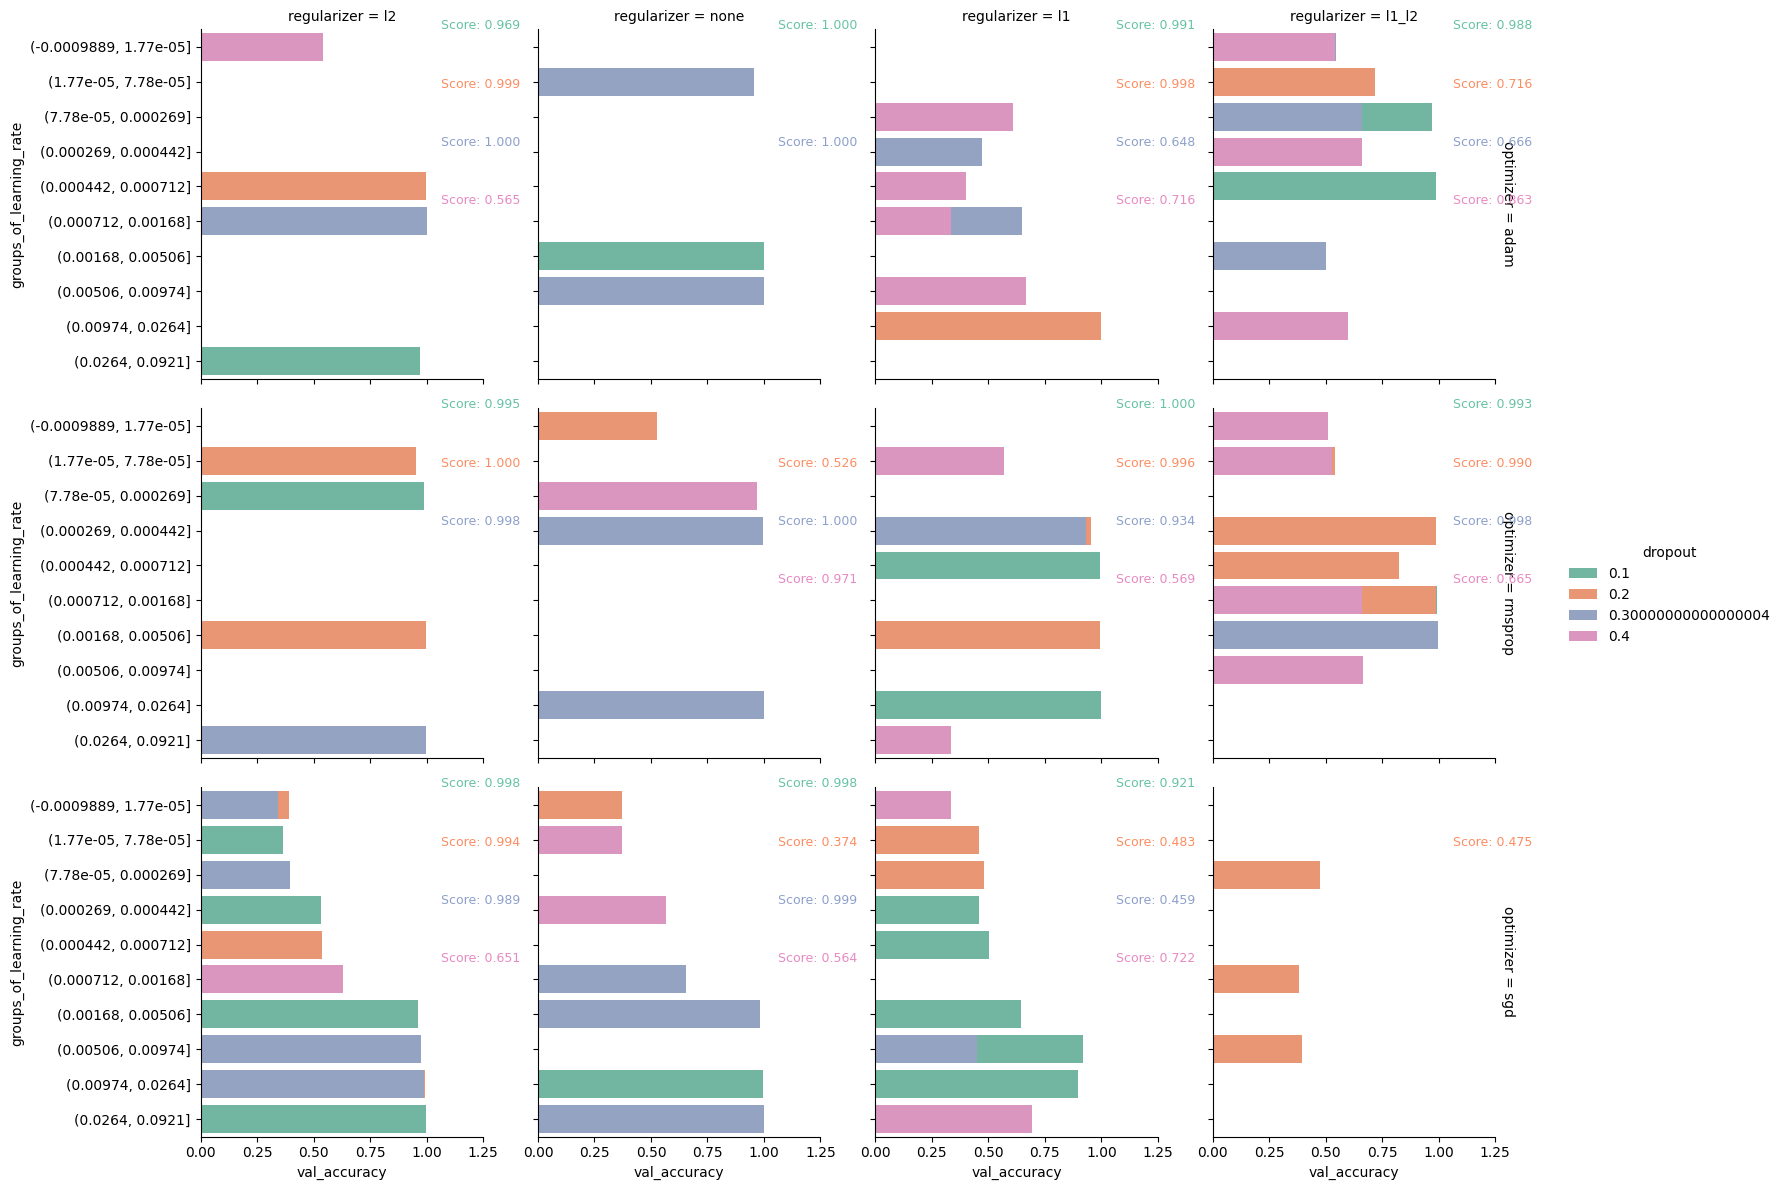

In [108]:
results_plot(tuner,num_trials=100,column="regularizer", row="optimizer", hue="dropout", x_var="learning_rate")